# PJR Verification -- Exploratory Data Analysis

Basic EDA over the results of a synthetic experiment grid
(`synthetic_data_tools/aaai_experiment.py`) and its PJR verification
(`verification/verify_pjr.py` / `multiprocessing_verify_pjr.py`).

Reads directly from the bundled, checked-in results archive
(`aaai_experiments/aaai_grid_synthetic_experiment.zip`) rather than a live
`experiments/` directory, so cloning the repo and running this notebook
reproduces the same analysis with no separate experiment/verification run
required. Everything below is read straight out of the zip -- nothing is
extracted to disk.

Loads the two notebook-friendly tables verification produces:

- **`pjr_results.jsonl`** -- one row per run: its configuration
  (n, m, T, sigma, point modes, approval_threshold, seed) plus
  `num_violations`, `satisfied`, `worst_gap`, `worst_group_size`.
- **`all_violations.jsonl`** -- one row per violating group across every
  run: the run's configuration plus `voters`, `group_size`, `agreement`,
  `bound`, `satisfaction`, `gap`.

Assumes this notebook is launched with the repository root as the
working directory (e.g. `task jupyter`, or `jupyter lab` run from the
repo root).

In [1]:
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Locate the archive

Jupyter sets the kernel's working directory to this notebook's own
folder (`src/eda/`), not the repo root, regardless of where you launched
Jupyter from -- so we find the repo root by walking up for `pyproject.toml`
rather than relying on a relative path.

In [2]:
def find_repo_root(marker: str = "pyproject.toml") -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' in any parent of {Path.cwd()}")


REPO_ROOT = find_repo_root()
ARCHIVE_PATH = REPO_ROOT / "aaai_experiments" / "aaai_grid_synthetic_experiment.zip"

if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        f"Results archive not found at {ARCHIVE_PATH} -- did you clone with the "
        "aaai_experiments/ directory intact?"
    )

print(f"Using archive: {ARCHIVE_PATH}")

Using archive: /home/tristan/repos/temporal_serial_dictator/aaai_experiments/aaai_grid_synthetic_experiment.zip


## Load the data

Both tables are read directly out of the zip via `zipfile`, without
extracting anything to disk.

In [3]:
with zipfile.ZipFile(ARCHIVE_PATH) as archive:
    with archive.open("pjr_results.jsonl") as f:
        results_df = pd.read_json(f, lines=True)
    with archive.open("all_violations.jsonl") as f:
        violations_df = pd.read_json(f, lines=True)

print(f"results_df:    {results_df.shape[0]:>6} rows (one per run)")
print(f"violations_df: {violations_df.shape[0]:>6} rows (one per violating group)")
results_df.head()

results_df:     10800 rows (one per run)
violations_df:   7126 rows (one per violating group)


,run,T,n,m,sigma,voter_point_mode,cand_point_mode,approval_threshold,seed,num_violations,satisfied,worst_gap,worst_group_size
0,run_0,5,5,10,0.2,eucl2,uniform_square,1.5,3796448083,0,True,NaN,NaN
1,run_1,5,5,10,0.2,eucl2,uniform_square,1.5,3796448083,0,True,NaN,NaN
2,run_2,5,5,10,0.2,eucl2,uniform_square,1.5,3796448083,0,True,NaN,NaN
3,run_3,5,5,10,0.2,eucl2,uniform_square,1.5,3796448083,0,True,NaN,NaN
4,run_4,5,5,10,0.2,eucl2,uniform_square,1.5,3796448083,0,True,NaN,NaN


## Overall summary

What fraction of runs satisfy PJR overall?

In [4]:
n_runs = len(results_df)
n_violating = (~results_df["satisfied"]).sum()

print(f"Total runs:            {n_runs}")
print(f"Runs satisfying PJR:   {n_runs - n_violating} ({(n_runs - n_violating) / n_runs:.1%})")
print(f"Runs violating PJR:    {n_violating} ({n_violating / n_runs:.1%})")
print(f"Total violating groups (all runs): {violations_df.shape[0]}")

Total runs:            10800
Runs satisfying PJR:   10298 (95.4%)
Runs violating PJR:    502 (4.6%)
Total violating groups (all runs): 7126


## Violation rate by configuration dimension

For each grid dimension (n, m, T, approval_threshold), what fraction of
runs at that value violate PJR?

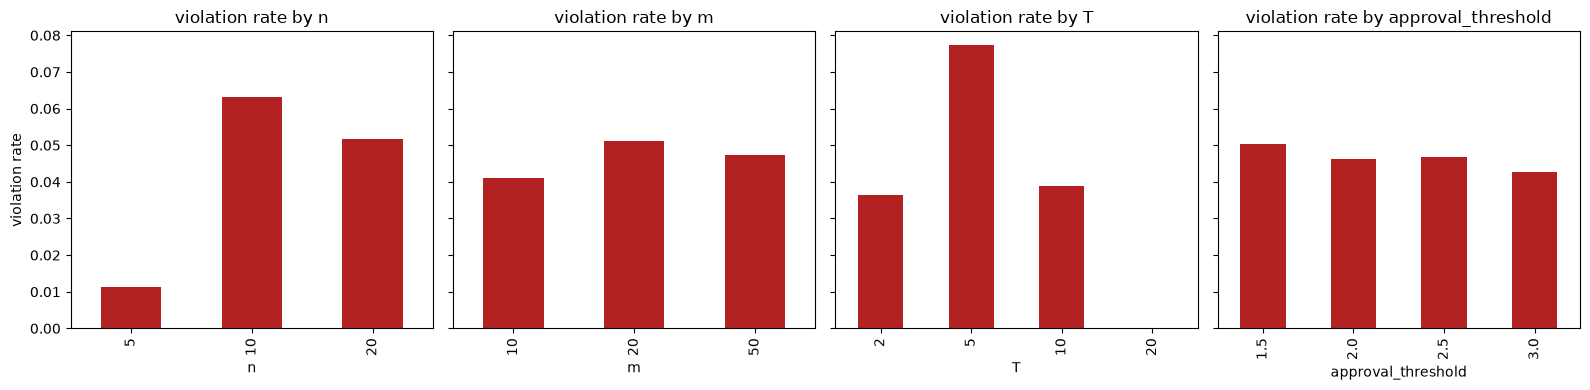

In [5]:
dimensions = ["n", "m", "T", "approval_threshold"]

fig, axes = plt.subplots(1, len(dimensions), figsize=(16, 4), sharey=True)
for ax, dim in zip(axes, dimensions, strict=True):
    rate = 1 - results_df.groupby(dim)["satisfied"].mean()
    rate.plot(kind="bar", ax=ax, color="firebrick")
    ax.set_title(f"violation rate by {dim}")
    ax.set_ylabel("violation rate")
    ax.set_xlabel(dim)
fig.tight_layout()

## Violation rate heatmap: n x T

Rounds (T) is derived per n in the grid, so most (n, T) combinations
only exist for one n -- this pivots whatever combinations are present.

T,2,5,10,20
n,,,,
5,0.022500,0.000000,NaN,NaN
10,0.050833,0.138333,0.0000,NaN
20,0.035833,0.093333,0.0775,0.0


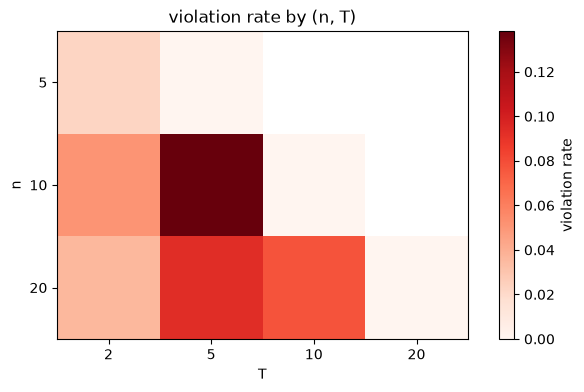

In [6]:
pivot = 1 - results_df.pivot_table(index="n", columns="T", values="satisfied", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=pivot.values[~pd.isna(pivot.values)].max())
ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns)
ax.set_yticks(range(len(pivot.index)), labels=pivot.index)
ax.set_xlabel("T")
ax.set_ylabel("n")
ax.set_title("violation rate by (n, T)")
fig.colorbar(im, ax=ax, label="violation rate")
pivot

## Distribution of violations per run

Most runs satisfy PJR outright (0 violations); this looks at the shape
of the distribution for the runs that don't.

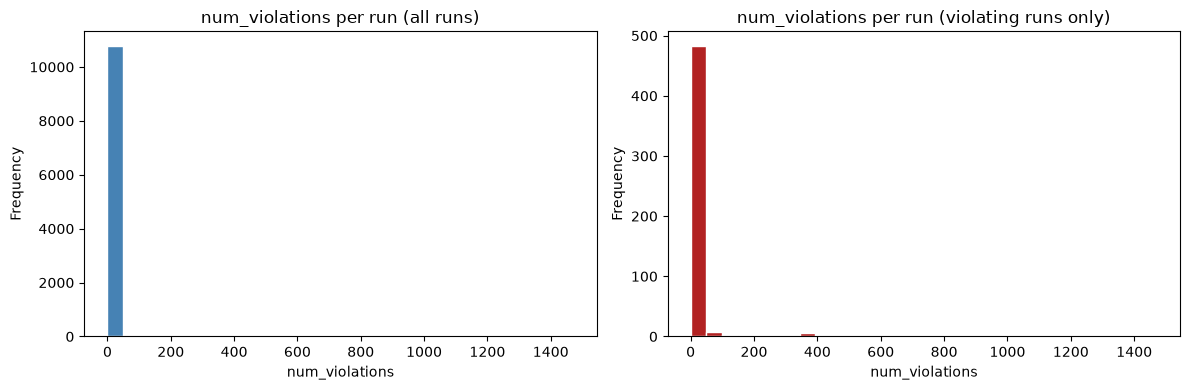

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df["num_violations"].plot(
    kind="hist", bins=30, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("num_violations per run (all runs)")
axes[0].set_xlabel("num_violations")

violating = results_df.loc[~results_df["satisfied"]]
violating["num_violations"].plot(
    kind="hist", bins=30, ax=axes[1], color="firebrick", edgecolor="white"
)
axes[1].set_title("num_violations per run (violating runs only)")
axes[1].set_xlabel("num_violations")
fig.tight_layout()

## Worst-case severity

`worst_gap` is `bound - satisfaction` for each run's single worst-violated
group -- how far short that group fell of its representation guarantee.

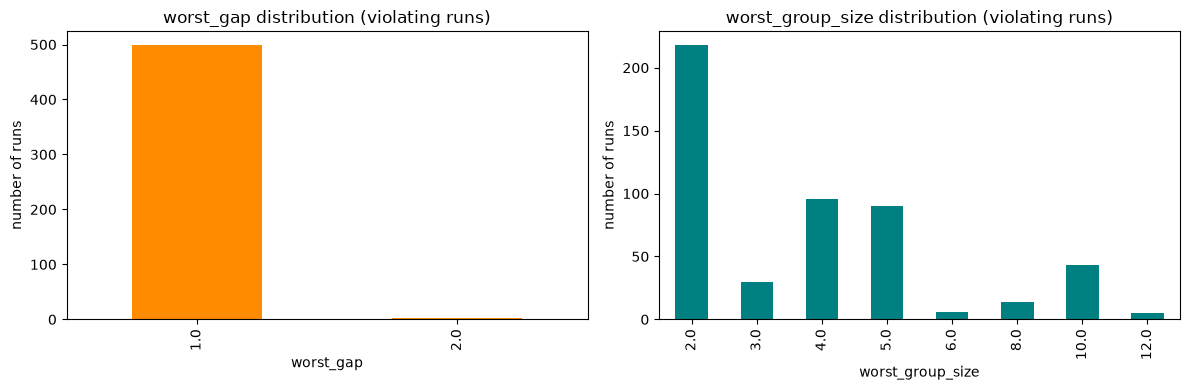

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

violating["worst_gap"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="darkorange"
)
axes[0].set_title("worst_gap distribution (violating runs)")
axes[0].set_xlabel("worst_gap")
axes[0].set_ylabel("number of runs")

violating["worst_group_size"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="teal"
)
axes[1].set_title("worst_group_size distribution (violating runs)")
axes[1].set_xlabel("worst_group_size")
axes[1].set_ylabel("number of runs")
fig.tight_layout()

## Violation-level analysis (`all_violations.jsonl`)

Every violating group across every run, not just each run's single worst
one -- lets us look at what kinds of groups tend to be under-served.

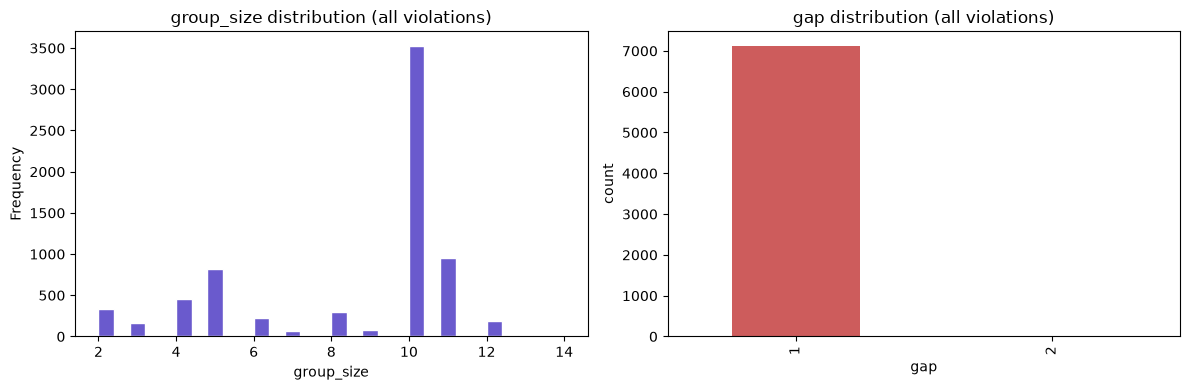

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

violations_df["group_size"].plot(
    kind="hist", bins=30, ax=axes[0], color="slateblue", edgecolor="white"
)
axes[0].set_title("group_size distribution (all violations)")
axes[0].set_xlabel("group_size")

violations_df["gap"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("gap distribution (all violations)")
axes[1].set_xlabel("gap")
axes[1].set_ylabel("count")
fig.tight_layout()

## Worst configurations

Which (n, m, T, threshold) configurations have the highest total violation
counts across their runs? (Mirrors the "Violations by configuration"
section of `pjr_summary.log`, but as a sortable/filterable table.)

In [10]:
config_cols = ["n", "m", "T", "approval_threshold"]

config_stats = (
    results_df.groupby(config_cols)
    .agg(
        num_runs=("run", "count"),
        num_violating_runs=("satisfied", lambda s: (~s).sum()),
        total_violations=("num_violations", "sum"),
        max_worst_gap=("worst_gap", "max"),
    )
    .assign(violation_rate=lambda df: df["num_violating_runs"] / df["num_runs"])
    .sort_values("total_violations", ascending=False)
)

config_stats.head(15)

num_runs  num_violating_runs  total_violations  max_worst_gap  violation_rate
n  m  T approval_threshold                                                                               
20 10 2 2.5                      100                   9              2326            1.0            0.09
   50 2 3.0                      100                   5               539            1.0            0.05
   20 5 3.0                      100                  17               483            1.0            0.17
   10 2 3.0                      100                   2               457            1.0            0.02
   20 2 2.0                      100                   4               394            1.0            0.04
   10 2 2.0                      100                   4               392            1.0            0.04
   20 2 3.0                      100                   7               223            1.0            0.07
   50 5 2.5                      100                   7               219            1.0            0.07
   10 5 2.0                      100                  12               194            1.0            0.12
      2 1.5                      100                   7               174            1.0            0.07
10 20 2 2.5                      100                  10               132            1.0            0.10
20 10 5 1.5                      100                  17               121            1.0            0.17
   20 5 1.5                      100                   9               116            1.0            0.09
10 10 2 2.0                      100                   8                89            1.0            0.08
        3.0                      100                   4                72            1.0            0.04

## Next steps

Some directions this could go further, depending on what you're
investigating:

- Join `violations_df` back to `results_df` on `run` to bring in the
  full run count context per violation.
- Look at whether `seed` (or specific `run`s) reproduce particularly bad
  configurations, using `generate_instance(..., seed=...)` to regenerate
  and inspect them directly.
- Compare synthetic results here against the real-data experiments (see
  `real_data_tools/real_aaai_experiment.py`'s output directories) once
  those are verified too.